# 💍 Wedding Organizer CBIR (Content-Based Image Retrieval) Playground
Notebook ini dirancang untuk melakukan **Eksplorasi Data**, **Ekstraksi Fitur**, dan **Uji Coba Pencarian Gambar Serupa (CBIR)** pada sistem Wedding Organizer Anda.

---

### 🚀 Fitur Utama Sistem CBIR:
1. **ResNet50 Deep Features (2048-dim)**: Ekstraksi fitur tingkat tinggi (semantik) menggunakan model pre-trained ResNet50.
2. **HSV Color Histogram (512-dim)**: Ekstraksi representasi warna dominan pada gambar.
3. **LBP (Local Binary Pattern) Texture (256-dim)**: Ekstraksi pola tekstur mikro pada dekorasi, pakaian, dll.
4. **Combined Weighted Features (2816-dim)**: Penggabungan ketiga fitur dengan bobot:
   $$\text{Combined} = 0.70 \times \text{Deep} + 0.20 \times \text{Color} + 0.10 \times \text{Texture}$$

In [3]:
import os
import sys
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Setup seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✓ Library berhasil di-import!")

✓ Library berhasil di-import!


## 📊 1. Eksplorasi Data (`dataset.csv`)
Langkah pertama adalah memuat data `dataset.csv` untuk memahami jumlah item, kategori, harga, dan sebaran data Wedding Organizer Anda.

In [4]:
csv_path = os.path.join("data", "dataset.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✓ Berhasil memuat dataset. Total data: {len(df)} baris.")
    display(df.head(3))
else:
    print("⚠ File data/dataset.csv tidak ditemukan. Harap pastikan file tersebut ada.")
    # Dummy data untuk visualisasi jika file tidak ditemukan
    df = pd.DataFrame({
        'ID': range(1, 6),
        'Type': ['product', 'product', 'package', 'product', 'package'],
        'Name': ['Gebyok Ukir Jati', 'Tenda Dekorasi', 'Paket Gold', 'Kursi Pelaminan', 'Paket Silver'],
        'Category': ['Traditional', 'Decoration', 'Complete', 'Decoration', 'Complete'],
        'Price': [15000000, 5000000, 35000000, 2000000, 20000000]
    })

✓ Berhasil memuat dataset. Total data: 20 baris.


,ID,Type,Name,Category,Price,Discount_Price,Organizer,Image_Path,Description,features
0,1,product,Gebyok Ukir Jati Premium,Traditional,15000000.0,NaN,Wedding Flower Decoration,D:\Weeding-Organizer-CBIR\Admin-Panel-Mobile\s...,Gebyok ukir kayu jati pilihan dengan motif bat...,"[0.04535010829567909, 0.21654163300991058, 0.3..."
1,2,product,Chandelier Kristal Modern,Modern,20000000.0,18000000.0,Wedding Flower Decoration,D:\Weeding-Organizer-CBIR\Admin-Panel-Mobile\s...,Chandelier kristal premium untuk dekorasi ball...,"[0.03863291069865227, 0.13172344863414764, 0.3..."
2,3,product,Arch Kayu Rustic Natural,Rustic,8500000.0,NaN,Wedding Flower Decoration,D:\Weeding-Organizer-CBIR\Admin-Panel-Mobile\s...,"Arch kayu alami dengan finishing natural, dihi...","[0.0908300131559372, 0.030194517225027084, 0.7..."


### Visualisasi Distribusi Kategori dan Tipe Item
Mari kita visualisasikan sebaran data berdasarkan **Tipe** (`product` vs `package`) dan **Kategori** produk.

C:\Users\ASUS TUF F15\AppData\Local\Temp\ipykernel_20716\3367109277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', palette='viridis', ax=axes[0])
C:\Users\ASUS TUF F15\AppData\Local\Temp\ipykernel_20716\3367109277.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='mako', ax=axes[1])


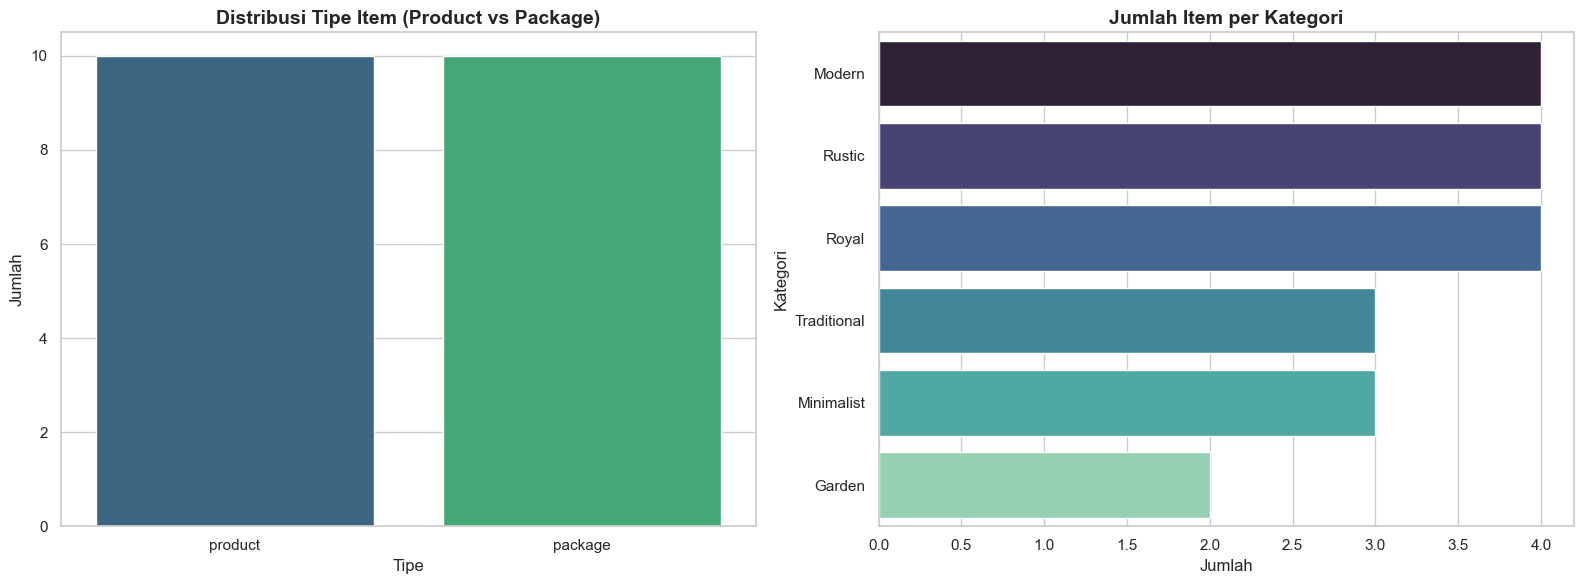

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribusi Tipe
sns.countplot(data=df, x='Type', palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Tipe Item (Product vs Package)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipe')
axes[0].set_ylabel('Jumlah')

# Plot 2: Distribusi Kategori
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='mako', ax=axes[1])
axes[1].set_title('Jumlah Item per Kategori', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah')
axes[1].set_ylabel('Kategori')

plt.tight_layout()
plt.show()

### Visualisasi Distribusi Harga Item
Melihat persebaran harga dekorasi/paket pernikahan untuk mengetahui rentang harga terpopuler.

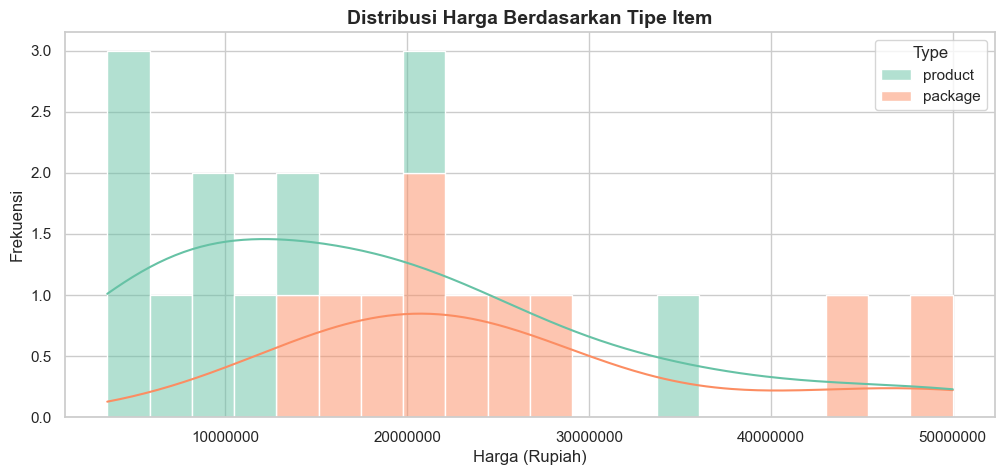

In [6]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Price', hue='Type', kde=True, bins=20, palette='Set2', multiple="stack")
plt.title('Distribusi Harga Berdasarkan Tipe Item', fontsize=14, fontweight='bold')
plt.xlabel('Harga (Rupiah)')
plt.ylabel('Frekuensi')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

## 🧬 2. Ekstraksi Fitur CBIR (ResNet50 + HSV Color + LBP Texture)
Kita akan memuat kelas `CBIREngine` yang didefinisikan dalam `cbir_engine.py` untuk memahami bagaimana proses ekstraksi fitur bekerja secara visual.

In [7]:
from cbir_engine import CBIREngine

# Inisialisasi CBIREngine
# Catatan: Inisialisasi pertama kali akan mengunduh model ResNet50 jika belum ada.
print("Sedang menginisialisasi CBIREngine...")
engine = CBIREngine(database_path="data")
print("✓ CBIREngine berhasil dimuat!")

Sedang menginisialisasi CBIREngine...
✓ CBIREngine berhasil dimuat!


### Memilih Gambar Sampel dari Dataset
Kita akan mengambil satu gambar dari dataset untuk dijadikan sampel demonstrasi ekstraksi fitur.

✓ Menemukan gambar sampel: Gebyok Ukir Jati Premium (D:\Weeding-Organizer-CBIR\Admin-Panel-Mobile\storage\app\public\4\product-1.png)


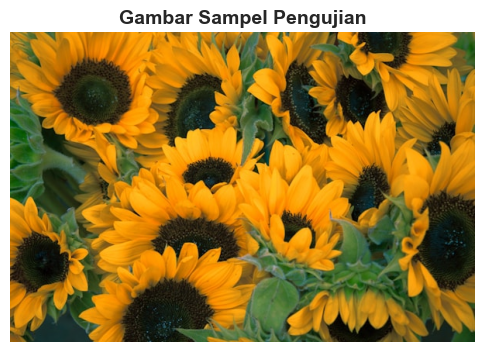

In [8]:
# Cari gambar yang benar-benar ada di local storage
sample_image_path = None
for idx, row in df.iterrows():
    path = row.get('Image_Path')
    if path and os.path.exists(path):
        sample_image_path = path
        print(f"✓ Menemukan gambar sampel: {row.get('Name')} ({path})")
        break

if not sample_image_path:
    # Jika tidak ada gambar riil, buat gambar dummy gradient untuk simulasi
    print("⚠ Tidak menemukan gambar riil di disk. Membuat gambar dummy untuk demo...")
    sample_image_path = "data/uploads/sample_dummy.png"
    os.makedirs(os.path.dirname(sample_image_path), exist_ok=True)
    dummy_img = np.zeros((256, 256, 3), dtype=np.uint8)
    cv2.circle(dummy_img, (128, 128), 80, (0, 165, 255), -1) # orange flower-like circle
    cv2.putText(dummy_img, "Dummy Wedding", (20, 135), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.imwrite(sample_image_path, dummy_img)
    print(f"✓ Gambar dummy dibuat di: {sample_image_path}")

# Tampilkan gambar sampel
img = Image.open(sample_image_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Gambar Sampel Pengujian", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

### Menjalankan Ekstraksi Fitur Lengkap
Sekarang kita panggil fungsi ekstraksi pada CBIREngine untuk mendapatkan:
- Fitur Deep ResNet50 (2048 dimensi)
- Fitur HSV Color Histogram (512 dimensi)
- Fitur LBP Texture (256 dimensi)
- Gabungan Fitur (2816 dimensi)

In [9]:
features = engine.extract_all_features(sample_image_path)

deep_f = np.array(features['deep_features'])
color_f = np.array(features['color_histogram'])
texture_f = np.array(features['texture_features'])
combined_f = np.array(features['combined_features'])

print(f"✓ Ekstraksi Selesai!")
print(f"  - Deep Features Dimension     : {deep_f.shape[0]}")
print(f"  - Color Histogram Dimension   : {color_f.shape[0]}")
print(f"  - Texture Features Dimension   : {texture_f.shape[0]}")
print(f"  - Combined Features Dimension  : {combined_f.shape[0]}")

✓ Ekstraksi Selesai!
  - Deep Features Dimension     : 2048
  - Color Histogram Dimension   : 512
  - Texture Features Dimension   : 256
  - Combined Features Dimension  : 2816


### 🎨 Visualisasi HSV Color Histogram & LBP Texture Histogram
Mari kita visualisasikan nilai-nilai fitur yang diekstrak agar kita bisa melihat bagaimana AI merepresentasikan gambar ini secara matematis.

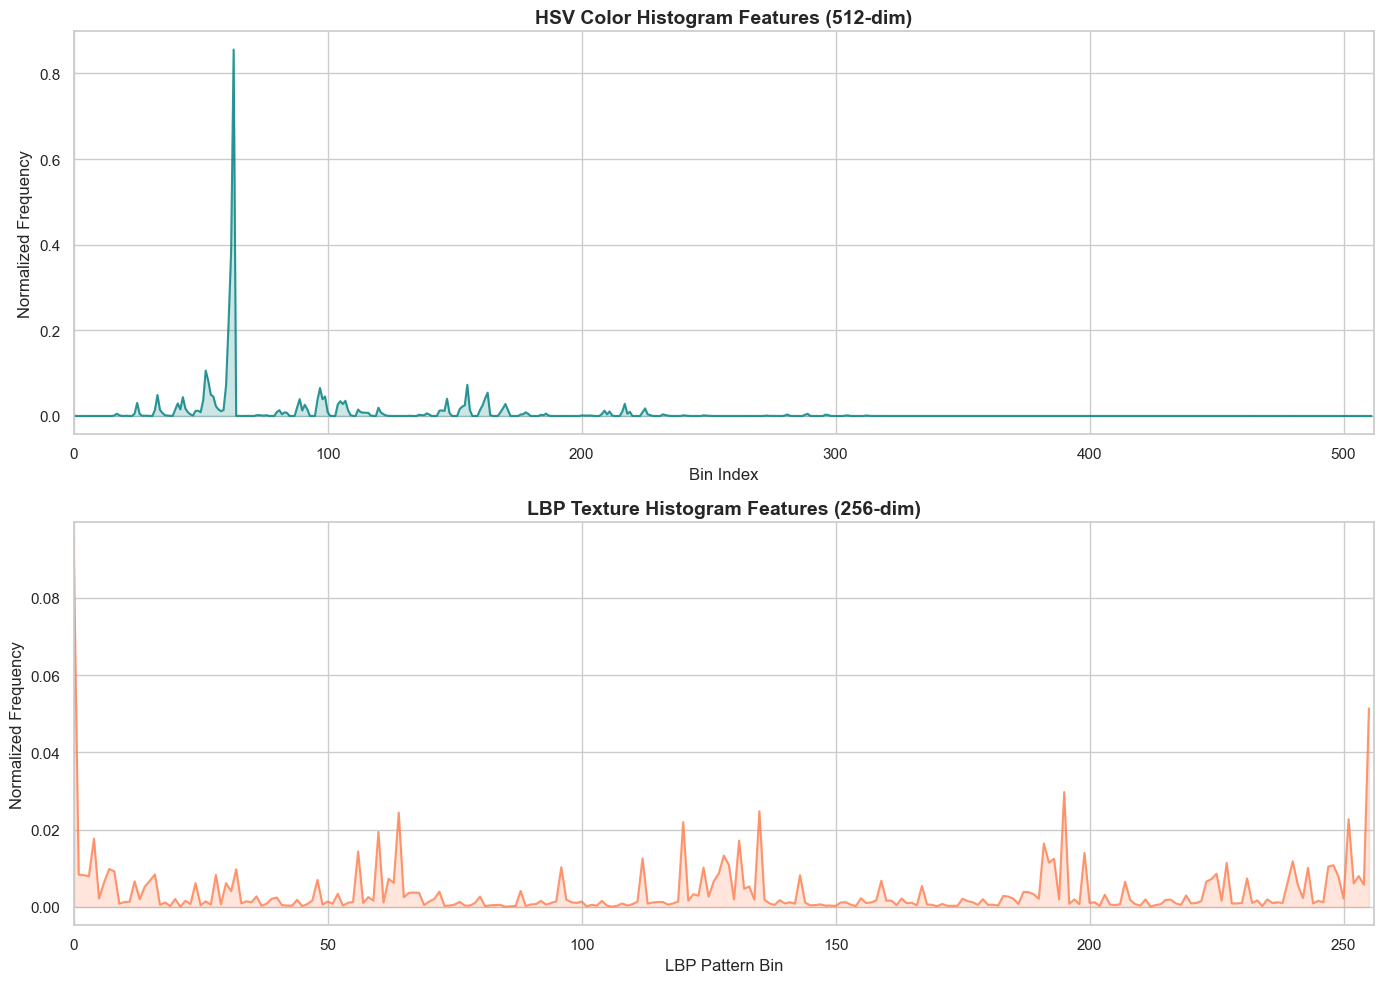

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Color Histogram
axes[0].plot(color_f, color='teal', alpha=0.8, linewidth=1.5)
axes[0].fill_between(range(len(color_f)), color_f, color='teal', alpha=0.2)
axes[0].set_title('HSV Color Histogram Features (512-dim)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Bin Index')
axes[0].set_ylabel('Normalized Frequency')
axes[0].set_xlim(0, len(color_f))

# Plot 2: Texture Features (LBP)
axes[1].plot(texture_f, color='coral', alpha=0.8, linewidth=1.5)
axes[1].fill_between(range(len(texture_f)), texture_f, color='coral', alpha=0.2)
axes[1].set_title('LBP Texture Histogram Features (256-dim)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LBP Pattern Bin')
axes[1].set_ylabel('Normalized Frequency')
axes[1].set_xlim(0, len(texture_f))

plt.tight_layout()
plt.show()

## 🔍 3. Demo Pencarian Gambar Serupa (CBIR Image Search)
Di bagian ini, kita akan menyimulasikan bagaimana cara kerja pencarian gambar serupa. Pengguna mengunggah sebuah gambar kueri (Query Image), dan sistem mencari gambar dengan fitur terdekat di dalam database.

In [11]:
# Lakukan pencarian menggunakan gambar sampel tadi
print("Memulai pencarian gambar yang paling mirip...")
search_results = engine.search_similar_images(sample_image_path, top_k=6)
print(f"✓ Berhasil mendapatkan {len(search_results)} hasil pencarian.")

Memulai pencarian gambar yang paling mirip...
✓ Berhasil mendapatkan 6 hasil pencarian.


### Menampilkan Hasil Pencarian Secara Visual
Kita akan menggambar Query Image di sebelah kiri, diikuti oleh hasil pencarian teratas di sebelah kanan beserta nilai **Similarity Score (%)** dan harganya.

C:\Users\ASUS TUF F15\AppData\Local\Temp\ipykernel_20716\1767866137.py:44: UserWarning: Glyph 128141 (\N{RING}) missing from font(s) Arial.
  plt.tight_layout()
d:\Weeding-Organizer-CBIR\ai_core\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128141 (\N{RING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


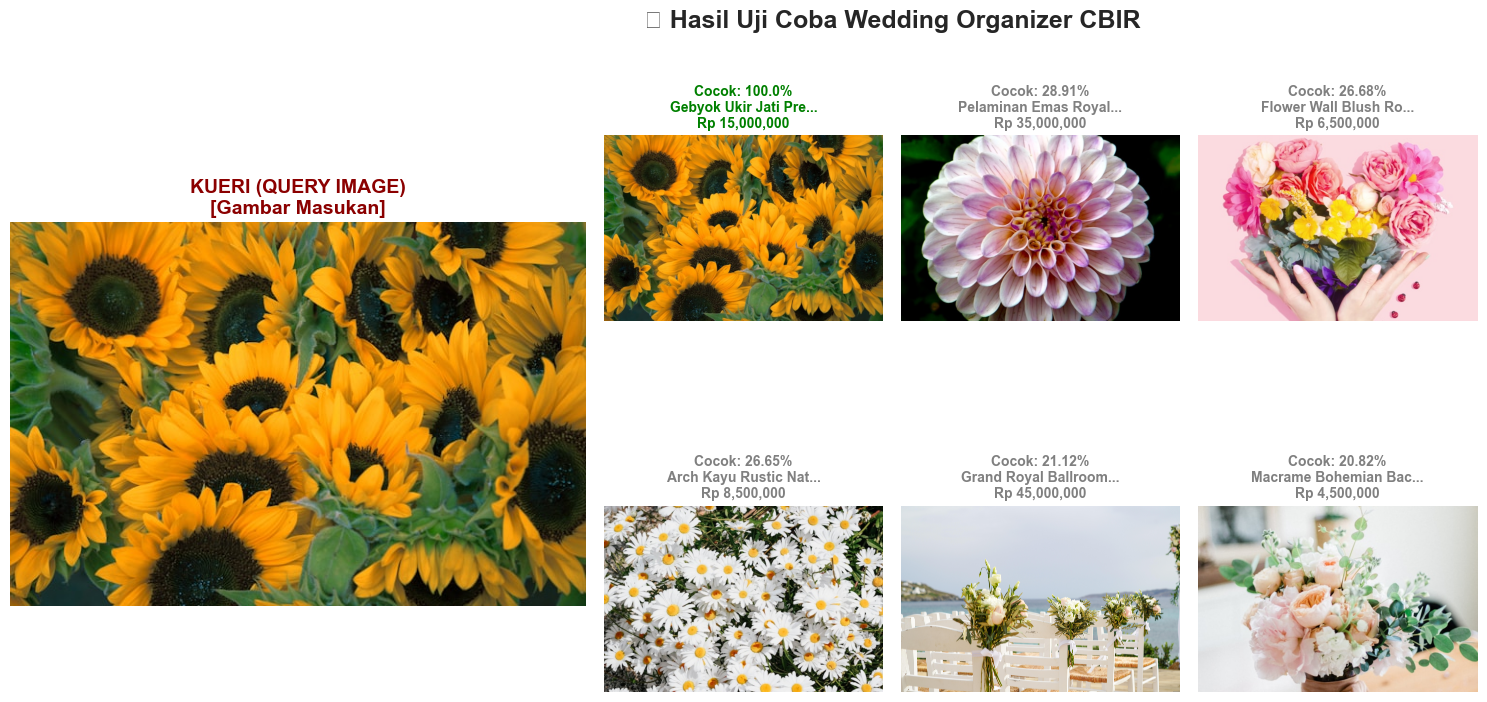

In [12]:
# Menampilkan gambar berdampingan
num_results = len(search_results)
fig = plt.figure(figsize=(18, 8))

# 1. Plot Query Image (Di Sisi Kiri)
ax_query = plt.subplot2grid((2, num_results), (0, 0), rowspan=2, colspan=2)
query_img = Image.open(sample_image_path)
ax_query.imshow(query_img)
ax_query.set_title("KUERI (QUERY IMAGE)\n[Gambar Masukan]", fontsize=14, color='darkred', fontweight='bold')
ax_query.axis('off')

# 2. Plot Hasil Pencarian (Di Sisi Kanan)
for i, res in enumerate(search_results):
    res_path = res['path']
    score = res['similarity']
    metadata = res['metadata']
    name = metadata.get('name', 'Unknown')
    price = metadata.get('price', 0)
    
    # Subplot untuk hasil pencarian ke-i
    # Kolom disesuaikan agar menyisakan ruang untuk query
    col_idx = 2 + i if i < (num_results - 2) else i
    if col_idx >= num_results:
        col_idx = num_results - 1
        
    ax_res = plt.subplot2grid((2, num_results), (0 if i < 3 else 1, 2 + (i % 3)))
    
    if os.path.exists(res_path):
        res_img = Image.open(res_path)
        ax_res.imshow(res_img)
    else:
        # Jika gambar database tidak ditemukan secara fisik, gunakan placeholder berwarna
        placeholder = np.zeros((150, 150, 3), dtype=np.uint8) + 220 # abu-abu terang
        cv2.putText(placeholder, "No Image", (30, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50, 50, 50), 1)
        ax_res.imshow(placeholder)
        
    # Judul yang menarik
    title_color = 'green' if score >= 75 else ('orange' if score >= 50 else 'gray')
    ax_res.set_title(f"Cocok: {score}%\n{name[:20]}...\nRp {price:,.0f}", 
                     fontsize=10, fontweight='bold', color=title_color)
    ax_res.axis('off')

plt.suptitle("💍 Hasil Uji Coba Wedding Organizer CBIR", fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 📐 4. Pemahaman Konversi Jarak ke Nilai Persentase Kemiripan (Similarity)
Sistem CBIR ini menggunakan **Jarak Euclidean** antara vektor fitur 2816 dimensi. 
Jarak Euclidean yang lebih kecil berarti gambar lebih mirip. 

Untuk memudahkan pengguna, jarak diubah menjadi **Persentase Kemiripan (Similarity Score 0 - 100%)** menggunakan rumus berikut:
1. **Linear Conversion (Skor Awal)**:
   $$\text{Linear} = \max\left(0, 100 - \left(\frac{\text{Distance}}{\text{Max Distance}} \times 100\right)\right)$$
2. **Quadratic Scaling (Memberikan efek gradasi kemiripan yang lebih sensitif)**:
   $$\text{Similarity} = \left(\frac{\text{Linear}}{100}\right)^2 \times 100$$
   *Skor di bawah 15% secara otomatis akan dibulatkan ke 0% (tidak cocok).*

Mari kita visualisasikan kurva pemetaan ini!

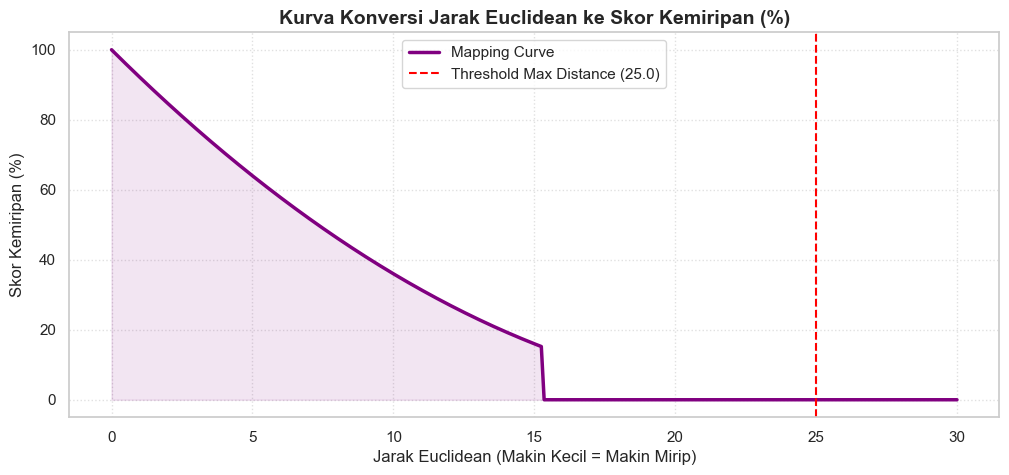

In [13]:
# Membuat simulasi jarak Euclidean dari 0 hingga 30
distances = np.linspace(0, 30, 300)
similarities = []

max_dist = 25.0
for dist in distances:
    linear = max(0.0, 100.0 - (dist / max_dist * 100.0))
    sim = (linear / 100.0) ** 2 * 100.0
    final_sim = sim if sim >= 15.0 else 0.0
    similarities.append(final_sim)

plt.figure(figsize=(12, 5))
plt.plot(distances, similarities, color='purple', linewidth=2.5, label='Mapping Curve')
plt.axvline(x=25.0, color='red', linestyle='--', label='Threshold Max Distance (25.0)')
plt.fill_between(distances, similarities, color='purple', alpha=0.1)

plt.title('Kurva Konversi Jarak Euclidean ke Skor Kemiripan (%)', fontsize=14, fontweight='bold')
plt.xlabel('Jarak Euclidean (Makin Kecil = Makin Mirip)')
plt.ylabel('Skor Kemiripan (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 🎉 Kesimpulan
Dengan playground Jupyter ini, Anda dapat:
1. **Memvalidasi dataset** Wedding Organizer Anda.
2. **Mengekstrak dan melihat** representasi fitur warna, tekstur, dan semantik AI.
3. **Menguji kecocokan pencarian** secara visual langsung dari notebook ini sebelum digunakan oleh aplikasi Laravel utama.

---
### 🛠 Tips Pengembangan Lebih Lanjut:
- Untuk menyinkronkan data baru dari database Laravel Anda, jalankan skrip build features:
  ```bash
  python rebuild_index.py
  ```
- Jalankan server Flask API untuk melayani pencarian dari aplikasi frontend Laravel Anda:
  ```bash
  python app.py
  ```